# Comparativa de Experimentos Non-IID
Lee todos los `*_Mean_global.csv` y genera tablas y gráficas comparativas.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

BASE = Path('.')

# ===========================================================
# Registro de experimentos: (escenario, param, path_glob)
# ===========================================================
EXPERIMENTS = [
    # (escenario,               param,    carpeta)
    ('IID Balanced',            'IID',    BASE / 'balanced/experimentos_balanced'),
    ('Gaussian Affine',         'σ=0.05', BASE / 'attribute_skew/gaussian_affine/experimentos_GaussianAffine_0.05'),
    ('Gaussian Affine',         'σ=0.3',  BASE / 'attribute_skew/gaussian_affine/experimentos_GaussianAffine_0.3'),
    ('Dirichlet (label skew)',  'α=0.5',  BASE / 'label_skew/Distribution-Based/experimentos_DirichletPartioner_0.5'),
    ('Dirichlet (label skew)',  'α=0.7',  BASE / 'label_skew/Distribution-Based/experimentos_DirichletPartioner_0.7'),
    ('Size Imbalance',          'α=2.0',  BASE / 'size_imbalance/experimentos_size_imbalanced_2.0')
]

# ===========================================================
# Cargar todos los CSVs
# ===========================================================
records = []
for escenario, param, folder in EXPERIMENTS:
    for csv_path in sorted(folder.glob('**/*_Clients_Mean_global.csv')):
        dataset   = csv_path.parent.name
        n_clients = int(csv_path.stem.split('_')[0])
        df = pd.read_csv(csv_path).set_index('metric')['mean']
        row = {'escenario': escenario, 'param': param,
               'dataset': dataset, 'n_clients': n_clients}
        row.update(df.to_dict())
        records.append(row)

df_all = pd.DataFrame(records)
df_all['label'] = df_all['escenario'] + ' ' + df_all['param']

# ===========================================================
# Paleta de colores por escenario
# ===========================================================
COLORS = {
    'IID Balanced IID':              '#4CAF50',
    'Gaussian Affine σ=0.05':        '#2196F3',
    'Gaussian Affine σ=0.3':         '#0D47A1',
    'Dirichlet (label skew) α=0.5':  '#FF9800',
    'Dirichlet (label skew) α=0.7':  '#E65100',
    'Size Imbalance α=0.5':          '#9C27B0',
    'Size Imbalance α=1.0':          '#4A148C',
}

print(f'Experimentos cargados: {len(df_all)}')
print(df_all[['escenario','param','dataset','n_clients']].to_string(index=False))

c:\Users\pablo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\pablo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Experimentos cargados: 20
             escenario  param                    dataset  n_clients
          IID Balanced    IID       adult_1500_instances          4
          IID Balanced    IID       adult_1500_instances          6
          IID Balanced    IID magic_gamma_1500_instances          4
          IID Balanced    IID magic_gamma_1500_instances          6
       Gaussian Affine σ=0.05       adult_1500_instances          4
       Gaussian Affine σ=0.05       adult_1500_instances          6
       Gaussian Affine σ=0.05 magic_gamma_1500_instances          4
       Gaussian Affine σ=0.05 magic_gamma_1500_instances          6
       Gaussian Affine  σ=0.3       adult_1500_instances          4
       Gaussian Affine  σ=0.3       adult_1500_instances          6
       Gaussian Affine  σ=0.3 magic_gamma_1500_instances          4
       Gaussian Affine  σ=0.3 magic_gamma_1500_instances          6
Dirichlet (label skew)  α=0.5       adult_1500_instances          4
Dirichlet (label skew)

In [2]:
# ===========================================================
# Métricas clave para la comparativa
# ===========================================================
METRICS = {
    # Q1 — Consistencia LORE
    'jaccard_lore_struct':               'Jaccard Struct. LORE',
    'sim_aditiva_lore':                  'Sim. Aditiva LORE',
    'jaccard_cov_localZ_LORE':           'Jaccard Cov. LORE (localZ)',
    'jaccard_cov_globalZ_LORE':          'Jaccard Cov. LORE (globalZ)',
    'cov_ruleLocal_on_localZ_LORE':      'Cov. Regla Local → Z_local',
    'cov_ruleGlobal_on_localZ_LORE':     'Cov. Regla Global → Z_local',
    'cov_ruleLocal_on_globalZ_LORE':     'Cov. Regla Local → Z_global',
    'cov_ruleGlobal_on_globalZ_LORE':    'Cov. Regla Global → Z_global',
    'covInter_localZ_LORE':              'Cov. Intersección LORE (localZ)',
    'covInter_globalZ_LORE':             'Cov. Intersección LORE (globalZ)',
    'covUnion_localZ_LORE':              'Cov. Unión LORE (localZ)',
    'covUnion_globalZ_LORE':             'Cov. Unión LORE (globalZ)',
    'has_factual_local':                 'Tiene factual LORE (local)',
    'has_factual_global':                'Tiene factual LORE (global)',
    'ratio_has_factual_localZ_LORE':     'Ratio factual LORE (localZ)',
    'ratio_has_factual_globalZ_LORE':    'Ratio factual LORE (globalZ)',
    # Q1 — Consistencia Anchor
    'jaccard_anchor_struct_testglobal':  'Jaccard Struct. Anchor (global test)',
    'jaccard_anchor_struct_testlocal':   'Jaccard Struct. Anchor (local test)',
    'sim_aditiva_anchor_testglobal':     'Sim. Aditiva Anchor (global test)',
    'sim_aditiva_anchor_testlocal':      'Sim. Aditiva Anchor (local test)',
    'anchor_prec_testglobal_local':      'Anchor Prec. Local (global test)',
    'anchor_prec_testglobal_global':     'Anchor Prec. Global (global test)',
    'anchor_prec_testlocal_local':       'Anchor Prec. Local (local test)',
    'anchor_prec_testlocal_global':      'Anchor Prec. Global (local test)',
    'anchor_cov_testglobal_local':       'Anchor Cov. Local (global test)',
    'anchor_cov_testglobal_global':      'Anchor Cov. Global (global test)',
    'anchor_cov_testlocal_local':        'Anchor Cov. Local (local test)',
    'anchor_cov_testlocal_global':       'Anchor Cov. Global (local test)',
    'ratio_has_anchor_testlocal_local':  'Ratio anchor local (local test)',
    'ratio_has_anchor_testlocal_global': 'Ratio anchor global (local test)',
    'ratio_has_anchor_testglobal_local': 'Ratio anchor local (global test)',
    'ratio_has_anchor_testglobal_global':'Ratio anchor global (global test)',
    # Q1 — Consistencia SHAP / LIME
    'delta_shap_testglobal':             'Δ SHAP (global test)',
    'delta_shap_testlocal':              'Δ SHAP (local test)',
    'delta_lime_testglobal':             'Δ LIME (global test)',
    'delta_lime_testlocal':              'Δ LIME (local test)',
    'pred_agreement_globalTest':         'Pred. Agreement (global test)',
    'pred_agreement_localTest':          'Pred. Agreement (local test)',
    # Q2 — Robustez / estabilidad
    'stability_shap_global':             'Estabilidad SHAP (global)',
    'stability_shap_local':              'Estabilidad SHAP (local)',
    'stability_lime_global':             'Estabilidad LIME (global)',
    'stability_lime_local':              'Estabilidad LIME (local)',
    'stability_anchor_testlocal_global': 'Estabilidad Anchor (global)',
    'stability_anchor_testlocal_local':  'Estabilidad Anchor (local)',
    'stability_lore_global':             'Estabilidad LORE (global)',
    'stability_lore_local':              'Estabilidad LORE (local)',
    'tree_fidelity_lore_global':         'Fidelidad Árbol LORE (global)',
    'tree_fidelity_lore_local':          'Fidelidad Árbol LORE (local)',
    'silhouette_global_LORE':            'Silhouette LORE (global)',
    'silhouette_local_LORE':             'Silhouette LORE (local)',
    # Rendimiento
    'acc_localTree_globalTest':          'Acc. Local Tree (global test)',
    'acc_localTree_localTest':           'Acc. Local Tree (local test)',
    'acc_nn_global_globalTest':          'Acc. NN Global (global test)',
    'acc_nn_global_localTest':           'Acc. NN Global (local test)',
    'acc_nn_local_globalTest':           'Acc. NN Local (global test)',
    'acc_nn_local_localTest':            'Acc. NN Local (local test)',
}

disponibles = [k for k in METRICS if k in df_all.columns]
faltantes   = [k for k in METRICS if k not in df_all.columns]
print(f"Métricas disponibles: {len(disponibles)}/{len(METRICS)}")
if faltantes:
    print(f"No encontradas en los CSVs: {faltantes}")

# ===========================================================
# TABLA RESUMEN — media sobre n_clients, por dataset
# ===========================================================
for dataset in sorted(df_all['dataset'].unique()):
    print(f'\n{"="*80}')
    print(f'  DATASET: {dataset}')
    print(f'{"="*80}')
    sub = df_all[df_all['dataset'] == dataset]
    cols = [c for c in METRICS if c in sub.columns]
    tabla = (
        sub.groupby('label')[cols]
           .mean()
           .rename(columns=METRICS)
    )
    order = ['IID Balanced IID',
             'Gaussian Affine σ=0.05', 'Gaussian Affine σ=0.3',
             'Dirichlet (label skew) α=0.8', 'Dirichlet (label skew) α=0.7',
             'Size Imbalance α=0.5', 'Size Imbalance α=1.0']
    tabla = tabla.reindex([o for o in order if o in tabla.index])
    with pd.option_context('display.max_columns', None, 'display.width', 200,
                           'display.float_format', '{:.3f}'.format):
        print(tabla.T.to_string())


Métricas disponibles: 56/56

  DATASET: adult_1500_instances
label                                 IID Balanced IID  Gaussian Affine σ=0.05  Gaussian Affine σ=0.3  Dirichlet (label skew) α=0.7
Jaccard Struct. LORE                             0.548                   0.569                  0.476                         0.648
Sim. Aditiva LORE                                0.654                   0.661                  0.583                         0.726
Jaccard Cov. LORE (localZ)                       0.566                   0.541                  0.548                         0.579
Jaccard Cov. LORE (globalZ)                      0.486                   0.477                  0.488                         0.508
Cov. Regla Local → Z_local                       0.564                   0.580                  0.548                         0.586
Cov. Regla Global → Z_local                      0.597                   0.646                  0.613                         0.697
Cov. Regla Loca

# Métricas principales

## Métricas de rendimiento del modelo

  RENDIMIENTO DEL MODELO  (media sobre 4/6 clientes)

  adult_1500_instances
                              NN_local / test=local  NN_global / test=local  NN_local / test=global  NN_global / test=global  Delta NN (G-L) local  Delta NN (G-L) global
label                                                                                                                                                                    
IID Balanced IID                              0.732                   0.742                   0.760                    0.762                 0.010                  0.001
Gaussian Affine σ=0.05                        0.742                   0.761                   0.754                    0.766                 0.019                  0.012
Gaussian Affine σ=0.3                         0.692                   0.683                   0.727                    0.713                -0.009                 -0.013
Dirichlet (label skew) α=0.5                  0.889                   0.6

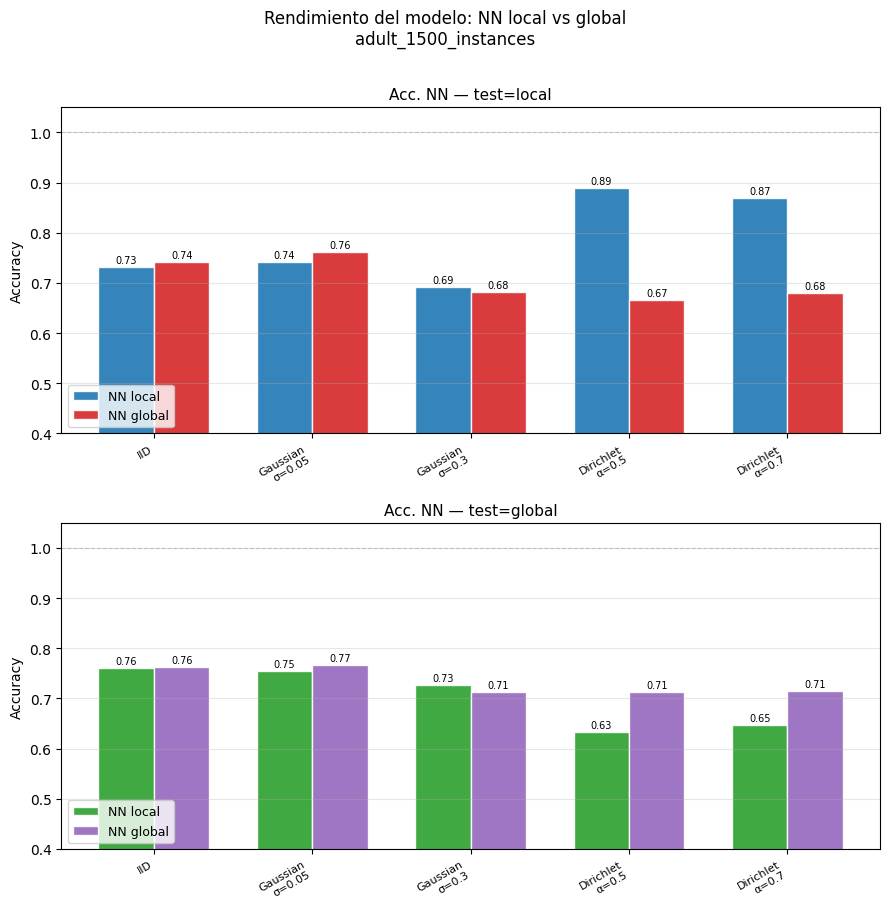

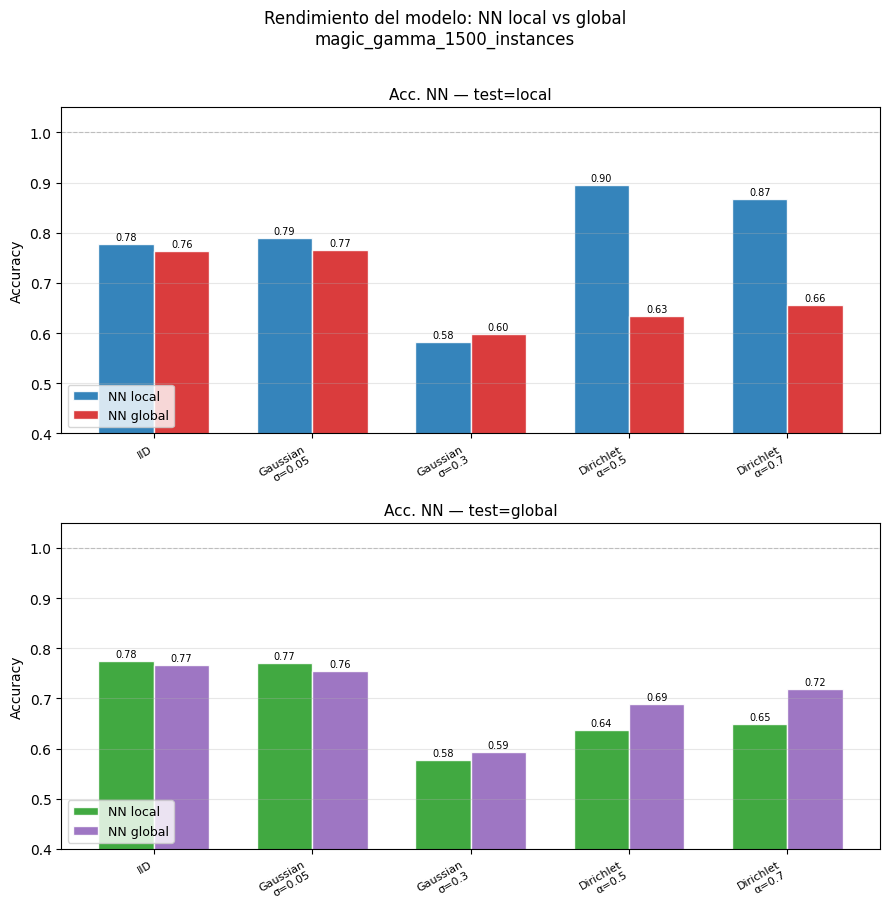

In [3]:
# ===========================================================
# Rendimiento del modelo: NN local vs global
#
# acc_nn_local_*  -> precision del black-box local (modelo del cliente)
# acc_nn_global_* -> precision del black-box global (modelo federado)
#
# Comparacion _localTest:  rendimiento en los datos del cliente
# Comparacion _globalTest: rendimiento en la distribucion global
# ===========================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7',
]

ACC_KEYS = [
    'acc_nn_local_localTest',  'acc_nn_global_localTest',
    'acc_nn_local_globalTest', 'acc_nn_global_globalTest',
]

datasets = sorted(df_all['dataset'].unique())

# -- Tabla ----------------------------------------------------------
print('=' * 80)
print('  RENDIMIENTO DEL MODELO  (media sobre 4/6 clientes)')
print('=' * 80)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    keys  = [k for k in ACC_KEYS if k in sub.columns]
    tabla = (
        sub.groupby('label')[keys].mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
           .rename(columns={
               'acc_nn_local_localTest':   'NN_local / test=local',
               'acc_nn_global_localTest':  'NN_global / test=local',
               'acc_nn_local_globalTest':  'NN_local / test=global',
               'acc_nn_global_globalTest': 'NN_global / test=global',
           })
    )
    tabla['Delta NN (G-L) local']  = tabla['NN_global / test=local']  - tabla['NN_local / test=local']
    tabla['Delta NN (G-L) global'] = tabla['NN_global / test=global'] - tabla['NN_local / test=global']
    print(f'\n  {dataset}')
    print(tabla.to_string(float_format=lambda x: f'{x:.3f}'))

# -- Grafica: figura separada por dataset, 2 filas (test=local / test=global) --
short_labels = lambda lst: [
    o.replace('Dirichlet (label skew) ', 'Dirichlet\n')
     .replace('Gaussian Affine ', 'Gaussian\n')
     .replace('IID Balanced ', '') for o in lst
]

rows_cfg = [
    (['acc_nn_local_localTest',  'acc_nn_global_localTest'],
     ['#1F77B4', '#D62728'], ['NN local', 'NN global'],
     'Acc. NN — test=local'),
    (['acc_nn_local_globalTest', 'acc_nn_global_globalTest'],
     ['#2CA02C', '#9467BD'], ['NN local', 'NN global'],
     'Acc. NN — test=global'),
]

from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
FIG_DIR = Path(_os.path.abspath("comparison_analysis.ipynb")).parent.parent / "resultados_metricas" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

for dataset in datasets:
    fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharey=True)
    sub_ds = df_all[df_all['dataset'] == dataset]
    orden  = [o for o in ORDER if o in sub_ds['label'].unique()]

    for row_idx, (keys, colors, labels, row_title) in enumerate(rows_cfg):
        avail = [k for k in keys if k in df_all.columns]
        ax    = axes[row_idx]
        t     = sub_ds.groupby('label')[avail].mean().reindex(orden)

        x     = np.arange(len(t))
        width = 0.35

        bars0 = ax.bar(x - width/2, t[avail[0]], width,
                       color=colors[0], alpha=0.9, edgecolor='white', label=labels[0])
        bars1 = ax.bar(x + width/2, t[avail[1]], width,
                       color=colors[1], alpha=0.9, edgecolor='white', label=labels[1])

        ax.set_xticks(x)
        ax.set_xticklabels(short_labels(orden), rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0.4, 1.05)
        ax.set_title(row_title, fontsize=11)
        ax.set_ylabel('Accuracy')
        ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=9, loc='lower left')

        for bar in list(bars0) + list(bars1):
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    fig.suptitle(f'Rendimiento del modelo: NN local vs global\n{dataset}',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'rendimiento_{dataset}.png', dpi=150, bbox_inches='tight')
    import shutil, pathlib
    plt.show()


### REVISAR POR QUE SALE TAN BIEN LA NN LOCAL EN TEST GLOBAL CUANDO NO DEBERIA SER ASI

Basicamente es por las bases de datos que hemos estado usando, la frontera de decision que se crea en breastcancer es muy diferente y tna solo con 3 instancias de una clase es capaz de saber diferenciar muy bien, o bien aprender de la otra clase tan sumamente bien que eso es lo que da lugar a que salgan tan buenos resultados.

- Con BreastCancer balanceado 50/50 (test global), local_global sigue siendo ~90% → el problema no es la distribución del test, es el dataset.
- Con Magic Gamma con distribuciones igual de extremas, local_global cae a 49-50% → el efecto Non-IID sí aparece.

La conclusión es que BreastCancer tiene una frontera de decisión universal y geométricamente muy separada — las células malignas forman un cluster tan distinto que incluso con 1-6 instancias de la clase minoritaria, la NN infiere correctamente dónde están las demás. No es un dataset válido para experimentos Non-IID de este tipo.

MIRAR PARAMETROS DE LAS REDES NEURONALES

DIFERENCIAS ENTRE LOS DATOS ORIGINALES Y LOS PUTEADOS

LA METODOLOGIA DE COMO SE HACEN LOS EXPERIMENTOS

## pred_agreement

Cuánto coinciden las predicciones del black-box local y del black-box global.

  P1: ACUERDO DE PREDICCIÓN LOCAL vs GLOBAL
  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                    0.841       0.829       0.012
Gaussian Affine σ=0.05              0.840       0.822       0.017
Gaussian Affine σ=0.3               0.806       0.793       0.013
Dirichlet (label skew) α=0.5        0.601       0.666      -0.065
Dirichlet (label skew) α=0.7        0.633       0.705      -0.073

  magic_gamma_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                    0.840       0.856      -0.016
Gaussian Affine σ=0.05              0.837       0.842      -0.006
Gaussian Affine σ=0.3               0.902       0.908      -0.005
Dirichlet (label skew) α=0.5        0.568       0.670      -0.102
Dirichlet (la

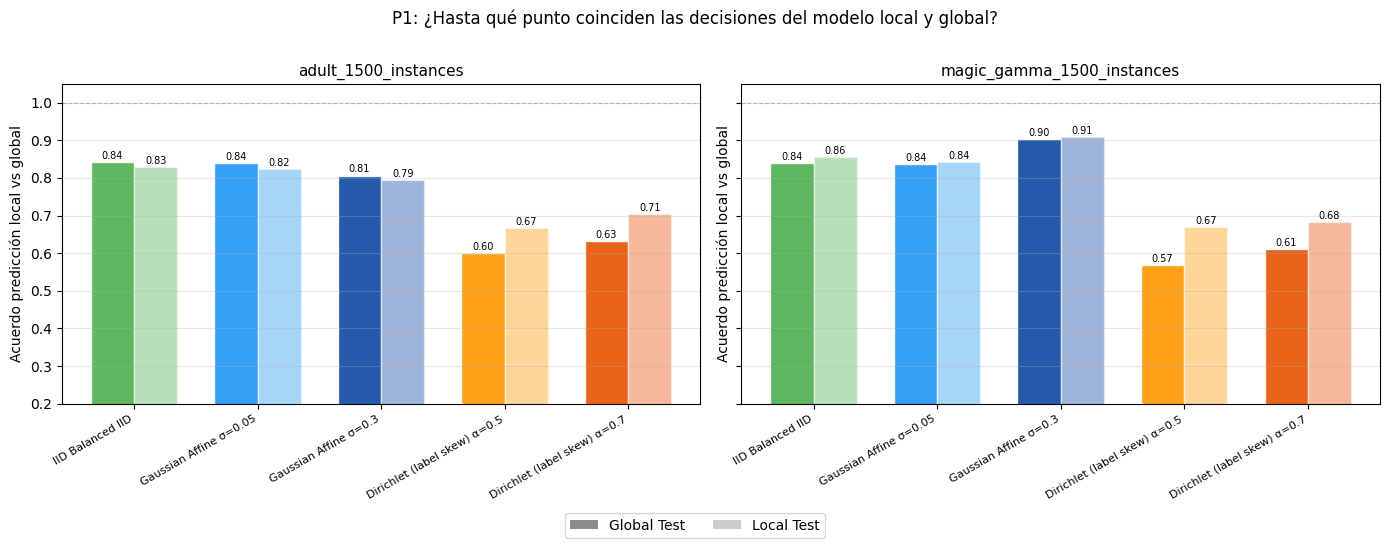

In [4]:

# ===========================================================
# P1: ¿Hasta qué punto el modelo local y el global
#     toman decisiones parecidas?
# Métrica: pred_agreement_globalTest / localTest
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7'
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  P1: ACUERDO DE PREDICCIÓN LOCAL vs GLOBAL")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['pred_agreement_globalTest', 'pred_agreement_localTest']]
           .mean()
           .rename(columns={'pred_agreement_globalTest': 'Global Test',
                            'pred_agreement_localTest':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['pred_agreement_globalTest', 'pred_agreement_localTest']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x      = np.arange(len(tabla))
    width  = 0.35
    colors = [COLORS.get(l, '#aaa') for l in tabla.index]

    bars_g = ax.bar(x - width/2, tabla['pred_agreement_globalTest'],
                    width, color=colors, alpha=0.9, edgecolor='white')
    bars_l = ax.bar(x + width/2, tabla['pred_agreement_localTest'],
                    width, color=colors, alpha=0.4, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.2, 1.05)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylabel('Acuerdo predicción local vs global')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='grey', alpha=0.9, label='Global Test'),
              Patch(facecolor='grey', alpha=0.4,  label='Local Test')]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)

plt.suptitle('P1: ¿Hasta qué punto coinciden las decisiones del modelo local y global?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pred_agreement.png', dpi=150, bbox_inches='tight')
plt.show()


# LORE

## Solapamiento entre reglas LORE

jaccard_cov_localZ / globalZ _LORE

  LORE: JACCARD COBERTURA  (media sobre 4/6/8 clientes)
  adult_1500_instances
                              localZ  globalZ
label                                        
IID Balanced IID               0.566    0.486
Gaussian Affine σ=0.05         0.541    0.477
Gaussian Affine σ=0.3          0.548    0.488
Dirichlet (label skew) α=0.5   0.509    0.474
Dirichlet (label skew) α=0.7   0.579    0.508
  magic_gamma_1500_instances
                              localZ  globalZ
label                                        
IID Balanced IID               0.682    0.727
Gaussian Affine σ=0.05         0.684    0.693
Gaussian Affine σ=0.3          0.693    0.699
Dirichlet (label skew) α=0.5   0.723    0.628
Dirichlet (label skew) α=0.7   0.703    0.586
  LORE: RATIO HAS FACTUAL  (media sobre 4/6/8 clientes)
  adult_1500_instances
                              localZ  globalZ
label                                        
IID Balanced IID               0.821    0.821
Gaussian Affine σ=0.05         

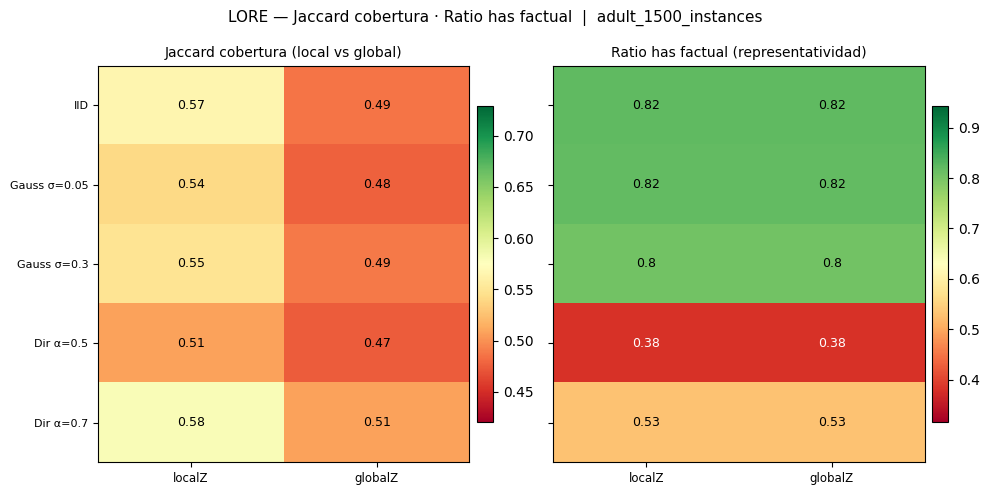

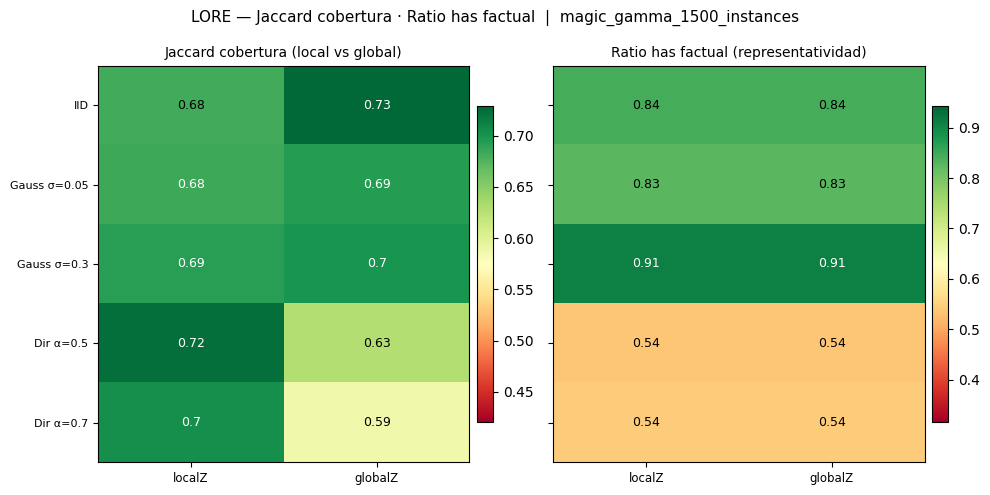

In [5]:
# P2: Jaccard de cobertura + ratio_has_factual de LORE
from pathlib import Path
import shutil
from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
FIG_DIR = Path(_os.path.abspath("comparison_analysis.ipynb")).parent.parent / "resultados_metricas" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

COV_KEYS   = ["jaccard_cov_localZ_LORE", "jaccard_cov_globalZ_LORE"]
RATIO_KEYS = ["ratio_has_factual_localZ_LORE", "ratio_has_factual_globalZ_LORE"]
COL_LABELS = ["localZ", "globalZ"]

ORDER = [
    "IID Balanced IID",
    "Gaussian Affine σ=0.05",
    "Gaussian Affine σ=0.3",
    "Dirichlet (label skew) α=0.5",
    "Dirichlet (label skew) α=0.7",
]

datasets = sorted(df_all["dataset"].unique())

short_labels = lambda lst: [
    o.replace("Dirichlet (label skew) ", "Dir ")
     .replace("Gaussian Affine ", "Gauss ")
     .replace("IID Balanced ", "") for o in lst
]

# ── Tablas ──────────────────────────────────────────────────────
sep = "=" * 72
for keys, title in [(COV_KEYS, "JACCARD COBERTURA"), (RATIO_KEYS, "RATIO HAS FACTUAL")]:
    print(sep)
    print("  LORE:", title, " (media sobre 4/6/8 clientes)")
    print(sep)
    for dataset in datasets:
        sub = df_all[df_all["dataset"] == dataset]
        tabla = (
            sub.groupby("label")[keys].mean()
               .rename(columns=dict(zip(keys, COL_LABELS)))
               .reindex([o for o in ORDER if o in sub["label"].unique()])
        )
        print("  " + dataset)
        print(tabla.to_string(float_format="{:.3f}".format))

# ── Heatmap: una figura por dataset (jaccard izq | ratio dcha) ──
cols_cfg = [
    (COV_KEYS,   "Jaccard cobertura (local vs global)"),
    (RATIO_KEYS, "Ratio has factual (representatividad)"),
]

for dataset in datasets:
    sub   = df_all[df_all["dataset"] == dataset]
    orden = [o for o in ORDER if o in sub["label"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for col_idx, (keys, col_title) in enumerate(cols_cfg):
        ax   = axes[col_idx]
        mat  = sub.groupby("label")[keys].mean().reindex(orden).values
        vmin = np.nanmin(df_all[keys].values)
        vmax = np.nanmax(df_all[keys].values)

        im = ax.imshow(mat, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(2))
        ax.set_xticklabels(COL_LABELS, fontsize=8.5)
        ax.set_yticks(range(len(orden)))
        ax.set_yticklabels(short_labels(orden) if col_idx == 0 else [], fontsize=8)
        ax.set_title(col_title, fontsize=10)

        mid = (vmin + vmax) / 2
        for i in range(len(orden)):
            for j in range(2):
                v = mat[i, j]
                c = "white" if abs(v - mid) > (vmax - vmin) * 0.35 else "black"
                ax.text(j, i, str(round(v, 2)), ha="center", va="center", fontsize=9, color=c)

        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

    fig.suptitle("LORE — Jaccard cobertura · Ratio has factual  |  " + dataset, fontsize=11)
    plt.tight_layout()
    fname = FIG_DIR / ("lore_jaccard_cobertura_factual_" + dataset + ".png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


> **Nota metodológica:** `ratio_has_factual` mide la fracción de instancias del test para las que LORE encontró una regla válida en ambos modelos. Cuando no la encuentra, esa instancia queda excluida del cálculo del Jaccard — por eso los valores son condicionalmente optimistas. La media entre clientes se pondera por número de instancias válidas para evitar que un cliente con pocas instancias tenga el mismo peso que uno con muchas.

# POR QUÉ LORE NO OBTIENE REGLA FACTUAL

  LORE - DESGLOSE DE FALLOS EN DIRICHLET  (media sobre 4/6 clientes)

  adult_1500_instances
                              has factual localZ LORE  fail monoclase only  fail disagreement only  fail both causes  fail noniid local  fail global only  fail geometric
label                                                                                                                                                                    
Dirichlet (label skew) α=0.5                    0.382                0.284                   0.131             0.203              0.481             0.001           0.004
Dirichlet (label skew) α=0.7                    0.532                0.175                   0.097             0.197              0.371             0.001           0.000

  magic_gamma_1500_instances
                              has factual localZ LORE  fail monoclase only  fail disagreement only  fail both causes  fail noniid local  fail global only  fail geometric
label                      

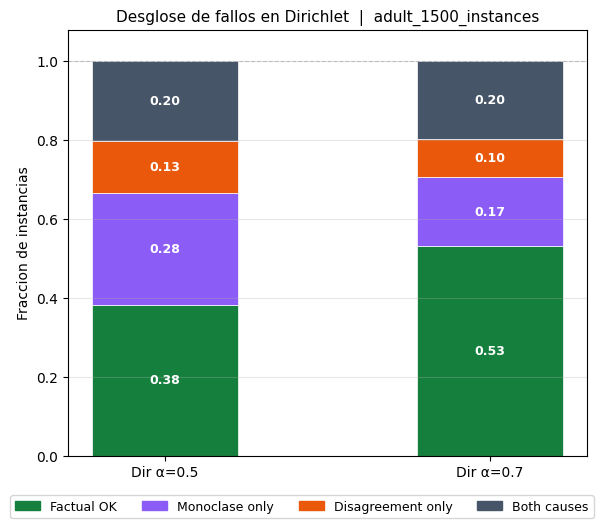

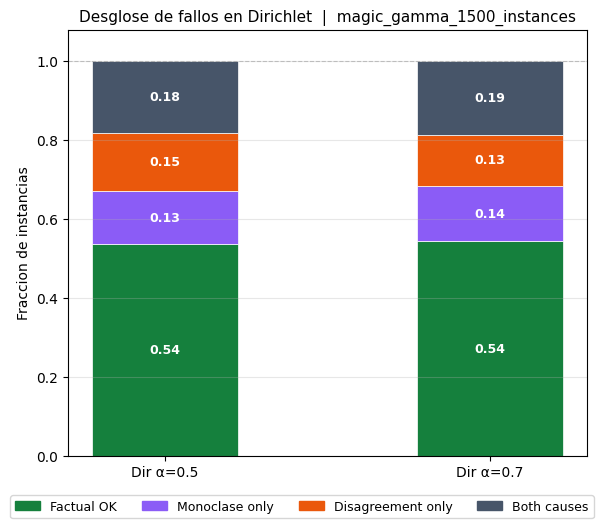


  Sub-descomposicion de monoclase
  noniid_local = monoclase_only + both_causes

  adult_1500_instances
                              noniid local  global only  geometric
label                                                             
Dirichlet (label skew) α=0.5         0.481        0.001      0.004
Dirichlet (label skew) α=0.7         0.371        0.001      0.000

  magic_gamma_1500_instances
                              noniid local  global only  geometric
label                                                             
Dirichlet (label skew) α=0.5         0.302        0.008      0.006
Dirichlet (label skew) α=0.7         0.319        0.004      0.004


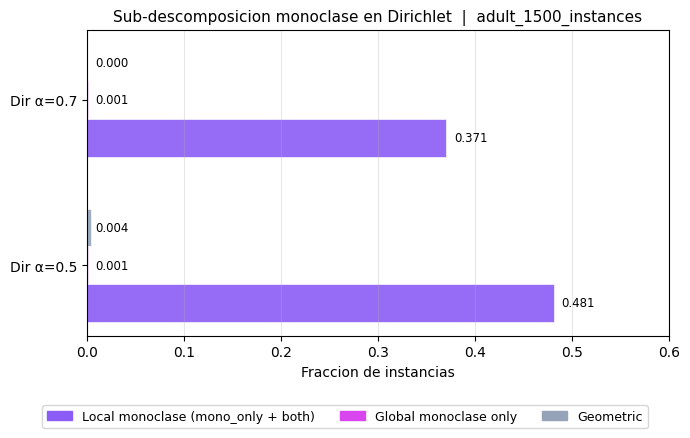

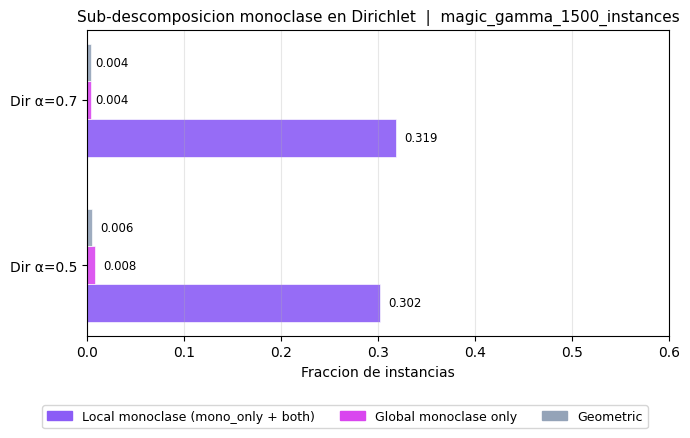

In [6]:
# =================================================================
# DIAGNOSTICO: ?Por que Dirichlet falla en ratio_has_factual?
# Descomposicion de fallos LORE en escenarios Dirichlet
# =================================================================
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
from pathlib import Path
import os as _os
FIG_DIR = Path(_os.path.abspath("comparison_analysis.ipynb")).parent.parent / "resultados_metricas" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DIRICHLET_LABELS = [
    "Dirichlet (label skew) α=0.5",
    "Dirichlet (label skew) α=0.7",
]

STACK_KEYS = [
    ("ratio_has_factual_localZ_LORE",   "#15803D", "Factual OK"),
    ("ratio_fail_monoclase_only",        "#8B5CF6", "Monoclase only"),
    ("ratio_fail_disagreement_only",     "#EA580C", "Disagreement only"),
    ("ratio_fail_both_causes",           "#475569", "Both causes"),
]
MONO_KEYS = [
    ("ratio_fail_noniid_local",  "#8B5CF6", "Local monoclase (mono_only + both)"),
    ("ratio_fail_global_only",   "#D946EF", "Global monoclase only"),
    ("ratio_fail_geometric",     "#94A3B8", "Geometric"),
]

datasets = sorted(df_all["dataset"].unique())
short = lambda s: s.replace("Dirichlet (label skew) ", "Dir ")

# -- Tabla -------------------------------------------------------
print("=" * 80)
print("  LORE - DESGLOSE DE FALLOS EN DIRICHLET  (media sobre 4/6 clientes)")
print("=" * 80)
all_keys = [k for k, _, _ in STACK_KEYS] + [k for k, _, _ in MONO_KEYS]
for dataset in datasets:
    sub = df_all[(df_all["dataset"] == dataset) &
                 (df_all["label"].isin(DIRICHLET_LABELS))]
    if sub.empty:
        continue
    cols = [k for k in all_keys if k in sub.columns]
    t = (sub.groupby("label")[cols].mean()
           .reindex([l for l in DIRICHLET_LABELS if l in sub["label"].unique()]))
    t.columns = [c.replace("ratio_", "").replace("_", " ") for c in t.columns]
    print(f"\n  {dataset}")
    print(t.to_string(float_format="{:.3f}".format))

# -- Stacked bar: una figura por dataset -------------------------
legend_patches = [mpatches.Patch(color=c, label=n) for _, c, n in STACK_KEYS]

for dataset in datasets:
    sub   = df_all[(df_all["dataset"] == dataset) &
                   (df_all["label"].isin(DIRICHLET_LABELS))]
    orden = [l for l in DIRICHLET_LABELS if l in sub["label"].unique()]
    keys  = [k for k, _, _ in STACK_KEYS if k in sub.columns]
    t     = sub.groupby("label")[keys].mean().reindex(orden)

    fig, ax = plt.subplots(figsize=(6, 5))
    x       = np.arange(len(orden))
    width   = 0.45
    bottoms = np.zeros(len(orden))

    for key, color, name in STACK_KEYS:
        if key not in t.columns:
            continue
        vals = t[key].fillna(0).values
        ax.bar(x, vals, width, bottom=bottoms, color=color, label=name,
               edgecolor="white", linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.04:
                ax.text(x[i], b + v / 2, f"{v:.2f}", ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels([short(l) for l in orden], fontsize=10)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Fraccion de instancias")
    ax.set_title(f"Desglose de fallos en Dirichlet  |  {dataset}", fontsize=11)
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.4)
    ax.grid(axis="y", alpha=0.3)
    fig.legend(handles=legend_patches, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, frameon=True)
    plt.tight_layout()
    fname = FIG_DIR / f"lore_fail_decomposition_dirichlet_{dataset}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

# -- Sub-descomposicion monoclase: una figura por dataset --------
print("\n" + "=" * 80)
print("  Sub-descomposicion de monoclase")
print("  noniid_local = monoclase_only + both_causes")
print("=" * 80)
mono_keys_list = [k for k, _, _ in MONO_KEYS]
for dataset in datasets:
    sub = df_all[(df_all["dataset"] == dataset) &
                 (df_all["label"].isin(DIRICHLET_LABELS))]
    if sub.empty:
        continue
    cols = [k for k in mono_keys_list if k in sub.columns]
    t = (sub.groupby("label")[cols].mean()
           .reindex([l for l in DIRICHLET_LABELS if l in sub["label"].unique()]))
    t.columns = [c.replace("ratio_fail_", "").replace("_", " ") for c in t.columns]
    print(f"\n  {dataset}")
    print(t.to_string(float_format="{:.3f}".format))

legend_patches2 = [mpatches.Patch(color=c, label=n) for _, c, n in MONO_KEYS]

for dataset in datasets:
    sub   = df_all[(df_all["dataset"] == dataset) &
                   (df_all["label"].isin(DIRICHLET_LABELS))]
    orden = [l for l in DIRICHLET_LABELS if l in sub["label"].unique()]
    keys  = [k for k, _, _ in MONO_KEYS if k in sub.columns]
    t     = sub.groupby("label")[keys].mean().reindex(orden)

    fig2, ax = plt.subplots(figsize=(7, 4))
    n_scenarios = len(orden)
    n_metrics   = len(MONO_KEYS)
    height      = 0.22
    y_base      = np.arange(n_scenarios) * (n_metrics * height + 0.3)
    offsets     = np.linspace(-(n_metrics-1)/2, (n_metrics-1)/2, n_metrics) * height

    for idx, (key, color, name) in enumerate(MONO_KEYS):
        if key not in t.columns:
            continue
        vals  = t[key].fillna(0).values
        y_pos = y_base + offsets[idx]
        bars  = ax.barh(y_pos, vals, height, color=color, label=name,
                        edgecolor="white", linewidth=0.5, alpha=0.9)
        for bar, v in zip(bars, vals):
            x_text = v + 0.008 if v >= 0.005 else 0.008
            ax.text(x_text, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", ha="left", va="center", fontsize=8.5)

    ax.set_yticks(y_base)
    ax.set_yticklabels([short(l) for l in orden], fontsize=10)
    ax.set_xlim(0, 0.6)
    ax.set_xlabel("Fraccion de instancias")
    ax.set_title(f"Sub-descomposicion monoclase en Dirichlet  |  {dataset}", fontsize=11)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.grid(axis="x", alpha=0.3)
    fig2.legend(handles=legend_patches2, loc="lower center", ncol=3,
                bbox_to_anchor=(0.5, -0.1), fontsize=9, frameon=True)
    plt.tight_layout()
    fname2 = FIG_DIR / f"lore_monoclase_subdecomp_dirichlet_{dataset}.png"
    fig2.savefig(fname2, dpi=150, bbox_inches="tight")
    plt.show()


## Estructura de las reglas LORE

`jaccard_lore_struct` — ¿usan las mismas features en las condiciones?  
`sim_aditiva_lore` — ¿las condiciones apuntan en la misma dirección y con magnitud similar?

  P3: SIMILITUD ESTRUCTURAL DE REGLAS LORE local vs global
  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Jaccard Struct  Sim. Aditiva  Diff (J-S)
label                                                                 
IID Balanced IID                       0.548         0.654      -0.105
Gaussian Affine σ=0.05                 0.569         0.661      -0.092
Gaussian Affine σ=0.3                  0.476         0.583      -0.107
Dirichlet (label skew) α=0.5           0.610         0.704      -0.094
Dirichlet (label skew) α=0.7           0.648         0.726      -0.078

  magic_gamma_1500_instances
                              Jaccard Struct  Sim. Aditiva  Diff (J-S)
label                                                                 
IID Balanced IID                       0.331         0.650      -0.319
Gaussian Affine σ=0.05                 0.336         0.652      -0.316
Gaussian Affine σ=0.3                  0.468         0.732      -0.264
Diri

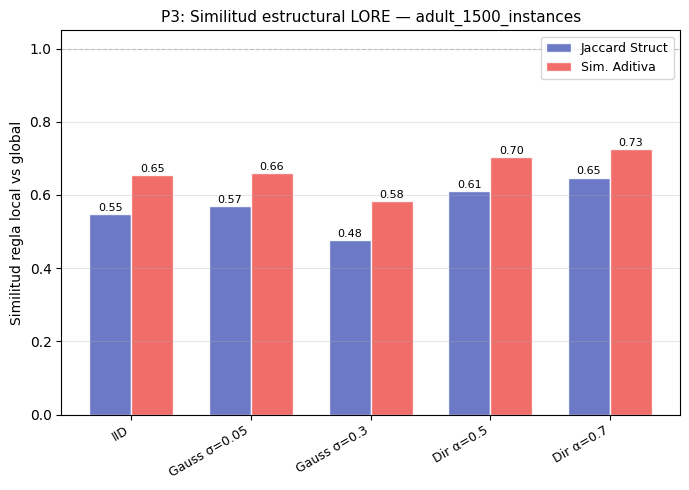

Guardado: lore_struct_similarity_adult_1500_instances.png


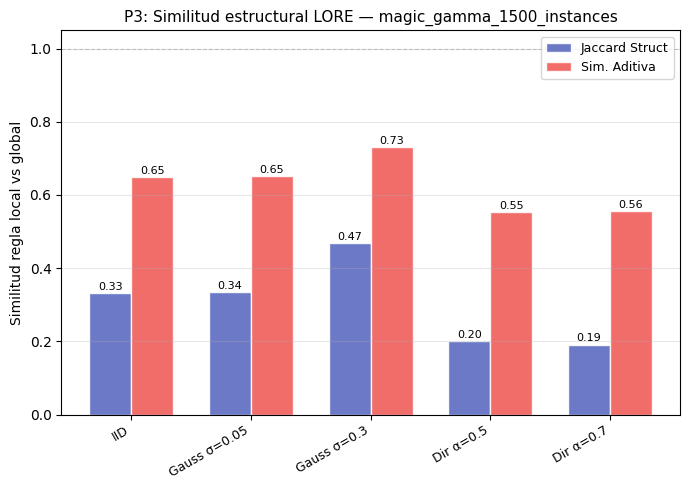

Guardado: lore_struct_similarity_magic_gamma_1500_instances.png


In [7]:
# ===========================================================
# P3: ¿Las explicaciones LORE locales y globales razonan
#     sobre las mismas variables?
#
# jaccard_lore_struct  → Jaccard entre el conjunto de features
#                        que aparecen en la regla local vs global
#                        (¿qué variables usan?)
# sim_aditiva_lore     → Similitud aditiva entre condiciones:
#                        tiene en cuenta dirección y magnitud
#                        (¿las condiciones son parecidas?)
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7',
]

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  P3: SIMILITUD ESTRUCTURAL DE REGLAS LORE local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['jaccard_lore_struct', 'sim_aditiva_lore']]
           .mean()
           .rename(columns={'jaccard_lore_struct': 'Jaccard Struct',
                            'sim_aditiva_lore':    'Sim. Aditiva'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (J-S)'] = tabla['Jaccard Struct'] - tabla['Sim. Aditiva']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica por dataset ────────────────────────────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['jaccard_lore_struct', 'sim_aditiva_lore']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    x     = np.arange(len(tabla))
    width = 0.35

    bars_j = ax.bar(x - width/2, tabla['jaccard_lore_struct'],
                    width, color='#5C6BC0', alpha=0.9, edgecolor='white',
                    label='Jaccard Struct')
    bars_s = ax.bar(x + width/2, tabla['sim_aditiva_lore'],
                    width, color='#EF5350', alpha=0.85, edgecolor='white',
                    label='Sim. Aditiva')

    ax.set_xticks(x)
    ax.set_xticklabels([short(l) for l in tabla.index], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f'P3: Similitud estructural LORE — {dataset}', fontsize=11)
    ax.set_ylabel('Similitud regla local vs global')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_j) + list(bars_s):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()

    fname = f'lore_struct_similarity_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

## Accuracy y fidelidad del árbol surrogate LORE

  LORE: FIDELIDAD DEL ÁRBOL SURROGATE  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Fidelidad bb_local  Fidelidad bb_global
label                                                                
IID Balanced IID                           0.948                0.967
Gaussian Affine σ=0.05                     0.948                0.963
Gaussian Affine σ=0.3                      0.948                0.968
Dirichlet (label skew) α=0.5               0.974                0.962
Dirichlet (label skew) α=0.7               0.968                0.964

  magic_gamma_1500_instances
                              Fidelidad bb_local  Fidelidad bb_global
label                                                                
IID Balanced IID                           0.969                0.970
Gaussian Affine σ=0.05                     0.970                0.968
Gaussian Affine σ=0.3                      0.969                0.970
Dirichlet (label skew) α=0.5          

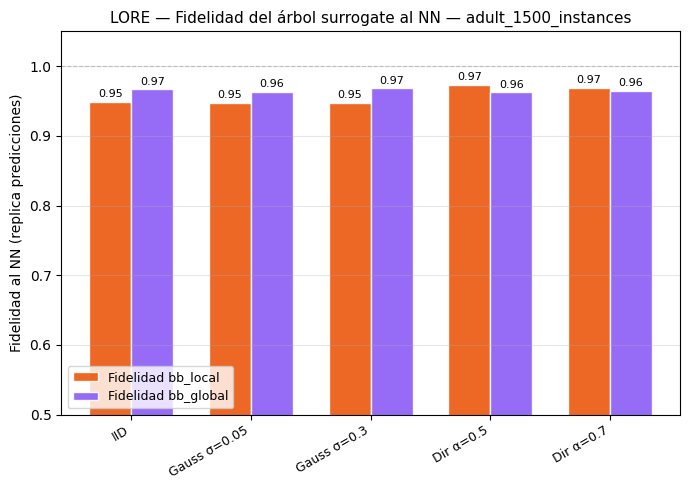

Guardado: lore_fidelity_adult_1500_instances.png


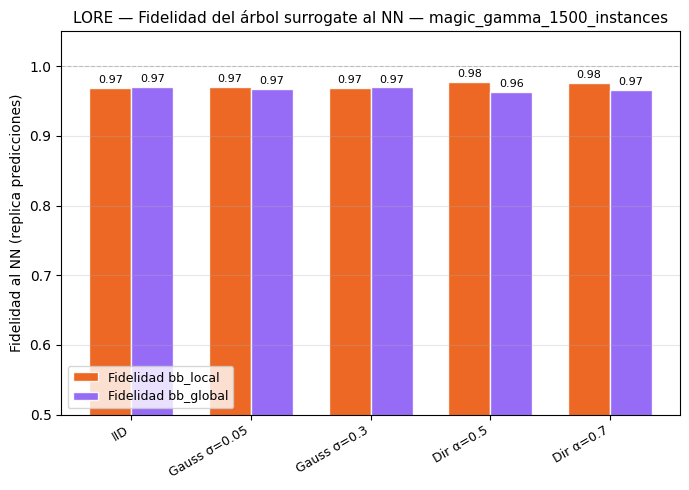

Guardado: lore_fidelity_magic_gamma_1500_instances.png


In [8]:
# ===========================================================
# LORE: Fidelidad del árbol surrogate al NN
#
# tree_fidelity_lore_local  → % instancias donde el árbol replica bb_local
# tree_fidelity_lore_global → % instancias donde el árbol replica bb_global
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7',
]

FID_KEYS = ['tree_fidelity_lore_local', 'tree_fidelity_lore_global']
datasets  = sorted(df_all['dataset'].unique())

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

COLOR_LOCAL  = '#EA580C'  # colorLoreLocal
COLOR_GLOBAL = '#8B5CF6'  # colorLoreGlobal

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  LORE: FIDELIDAD DEL ÁRBOL SURROGATE  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    avail = [k for k in FID_KEYS if k in sub.columns]
    tabla = (
        sub.groupby('label')[avail].mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
           .rename(columns={
               'tree_fidelity_lore_local':  'Fidelidad bb_local',
               'tree_fidelity_lore_global': 'Fidelidad bb_global',
           })
    )
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica por dataset ────────────────────────────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    avail = [k for k in FID_KEYS if k in sub.columns]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    t     = sub.groupby('label')[avail].mean().reindex(orden)

    fig, ax = plt.subplots(figsize=(7, 5))
    x     = np.arange(len(t))
    width = 0.35

    bars0 = ax.bar(x - width/2, t[avail[0]], width,
                   color=COLOR_LOCAL, alpha=0.9, edgecolor='white', label='Fidelidad bb_local')
    bars1 = ax.bar(x + width/2, t[avail[1]], width,
                   color=COLOR_GLOBAL, alpha=0.9, edgecolor='white', label='Fidelidad bb_global')

    ax.set_xticks(x)
    ax.set_xticklabels([short(o) for o in orden], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f'LORE — Fidelidad del árbol surrogate al NN — {dataset}', fontsize=11)
    ax.set_ylabel('Fidelidad al NN (replica predicciones)')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='lower left')

    for bar in list(bars0) + list(bars1):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    fname = f'lore_fidelity_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

# Conclusión sobre LORE

Cuando LORE explica la predicción de un modelo, construye una regla del tipo "si glucosa < 120 y BMI < 25, entonces clase A". La pregunta es: ¿la regla de bb_local y la de bb_global son comparables? Los datos dan tres respuestas:

1. **El surrogate imita bien al NN** — las reglas son técnicamente correctas respecto a lo que el modelo hace. La heterogeneidad no afecta a esto.

2. **Cubren instancias parecidas** — bb_local y bb_global generan regla para más o menos las mismas instancias. Excepción: Dirichlet, donde el label skew hace que más instancias queden cerca de la frontera sin regla posible.

3. **No usan las mismas features** — uno dice "glucosa y BMI", el otro dice "glucosa y edad". Cuando coinciden en una variable, las condiciones apuntan en la misma dirección — el problema no es contradicción sino divergencia en la elección de variables.

**El resultado:** bb_local y bb_global predicen igual, sus surrogates los imitan bien y explican las mismas instancias — pero cada uno destaca variables distintas. La explicación global no te dice cómo razona tu modelo local. Y esto ocurre incluso en IID — no es un problema del non-IID sino estructural del método.

**Limitación y mejoras:** el Jaccard struct bajo refleja en parte variabilidad del método, no solo divergencia entre modelos. Dos mejoras posibles: (1) ejecutar LORE varias veces y quedarse con las features más consistentes; (2) fijar las features de referencia a partir de importancias globales (p.ej. SHAP) antes de generar el vecindario.

MIRAR LA DIFERENCIA DE PARAMETROS DE LAS REDES NEUONALES

---

# LIME

## Delta LIME

  LIME: DELTA — diferencia media de importancias local vs global
  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0167      0.0163      0.0003
Gaussian Affine σ=0.05             0.0164      0.0158      0.0006
Gaussian Affine σ=0.3              0.0178      0.0172      0.0005
Dirichlet (label skew) α=0.5       0.0202      0.0199      0.0003
Dirichlet (label skew) α=0.7       0.0176      0.0176      0.0000

  magic_gamma_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0555      0.0551      0.0004
Gaussian Affine σ=0.05             0.0592      0.0593     -0.0001
Gaussian Affine σ=0.3              0.0796      0.0793      0.0003
Dirichlet (label skew) α=0.5       0.0828      0.0829     

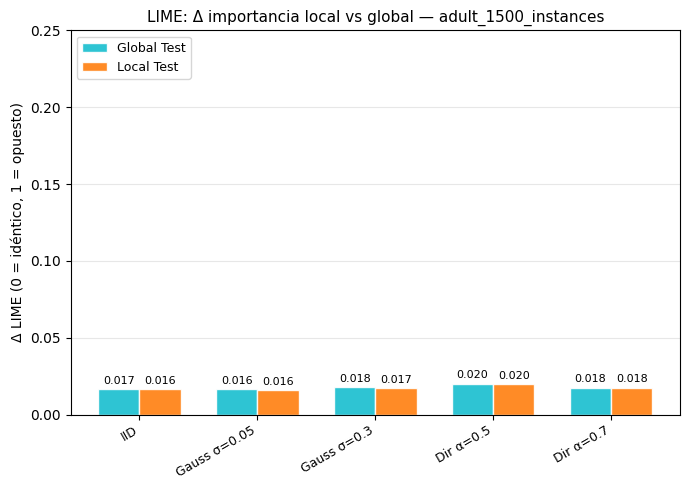

Guardado: lime_feature_importance_adult_1500_instances.png


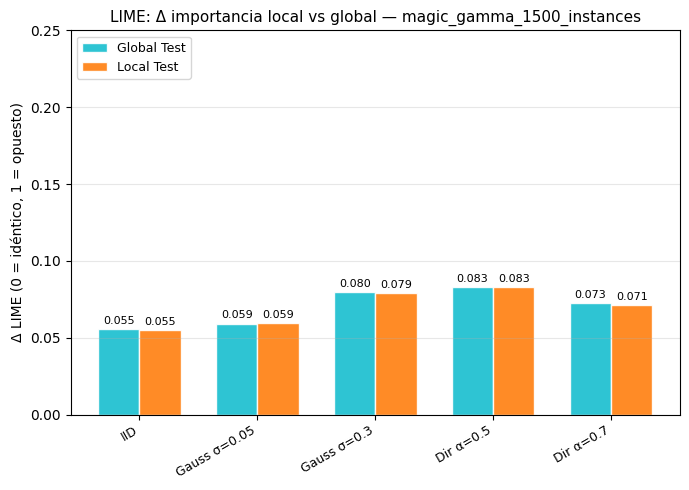

Guardado: lime_feature_importance_magic_gamma_1500_instances.png


In [9]:
# ===========================================================
# LIME: ¿Asignan el modelo local y el global la misma
#       importancia a las mismas features?
# Métrica: delta_lime_testglobal / delta_lime_testlocal
#   → diferencia media (L1) entre los vectores de importancia
#     del modelo local y del global, normalizados a L1=1
#   → 0 = idénticos; 1 = completamente distintos
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7',
]

datasets = sorted(df_all['dataset'].unique())

COLOR_LOCAL  = '#FF7F0E'  # colorAgreementLocal  → Local Test
COLOR_GLOBAL = '#17BECF'  # colorAgreementGlobal → Global Test

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  LIME: DELTA — diferencia media de importancias local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_lime_testglobal', 'delta_lime_testlocal']]
           .mean()
           .rename(columns={'delta_lime_testglobal': 'Global Test',
                            'delta_lime_testlocal':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.4f}'.format))

# ── Gráfica por dataset ────────────────────────────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_lime_testglobal', 'delta_lime_testlocal']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x     = np.arange(len(tabla))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))

    bars_g = ax.bar(x - width/2, tabla['delta_lime_testglobal'],
                    width, color=COLOR_GLOBAL, alpha=0.9, edgecolor='white',
                    label='Global Test')
    bars_l = ax.bar(x + width/2, tabla['delta_lime_testlocal'],
                    width, color=COLOR_LOCAL,  alpha=0.9, edgecolor='white',
                    label='Local Test')

    ax.set_xticks(x)
    ax.set_xticklabels([short(o) for o in tabla.index], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.0, 0.25)
    ax.set_title(f'LIME: Δ importancia local vs global — {dataset}', fontsize=11)
    ax.set_ylabel('Δ LIME (0 = idéntico, 1 = opuesto)')
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()

    fname = f'lime_feature_importance_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

**¿Asignan el bb_local y el bb_global la misma importancia a las features según LIME?**

En general sí — ambos deltas son bajos en todos los escenarios, lo que indica que bb_local y bb_global asignan importancias similares independientemente de si las perturbaciones vienen de la distribución local o de la global.

**Diabetes:** el delta es bajo en todos los escenarios. Dirichlet introduce algo más de divergencia por el label skew, aunque sigue siendo moderada.

**BreastCancer:** valores incluso más bajos. Esto es en parte un artefacto de escala: al normalizar L1=1 sobre 30 variables, cada feature ocupa un peso pequeño, por lo que las diferencias numéricas son diminutas aunque los modelos ordenen las features de forma distinta.

**Conclusión y limitación:** LIME muestra que la federación alinea bien los vectores de importancia. Pero el delta tiene un sesgo en alta dimensión: con 30 features el denominador es mayor y el delta sale bajo no porque los modelos coincidan más, sino por puro efecto de escala. SHAP, que compara el vector completo sin ese efecto, muestra más divergencia en BreastCancer. LIME es útil como métrica complementaria, pero no suficiente por sí sola en alta dimensión.

**Mejora propuesta:** comparar el ranking de las top-k features en lugar del delta sobre el vector completo. Dos modelos pueden tener delta bajo pero ordenar las features de forma distinta, y eso es lo que le importa al usuario que lee la explicación.

---

## Delta SHAP

  SHAP: DELTA — diferencia media de importancias local vs global
  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0229      0.0235     -0.0006
Gaussian Affine σ=0.05             0.0233      0.0231      0.0002
Gaussian Affine σ=0.3              0.0236      0.0236     -0.0000
Dirichlet (label skew) α=0.5       0.0230      0.0234     -0.0005
Dirichlet (label skew) α=0.7       0.0231      0.0236     -0.0005

  magic_gamma_1500_instances
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0577      0.0586     -0.0009
Gaussian Affine σ=0.05             0.0622      0.0641     -0.0019
Gaussian Affine σ=0.3              0.0860      0.0843      0.0017
Dirichlet (label skew) α=0.5       0.0811      0.0865     

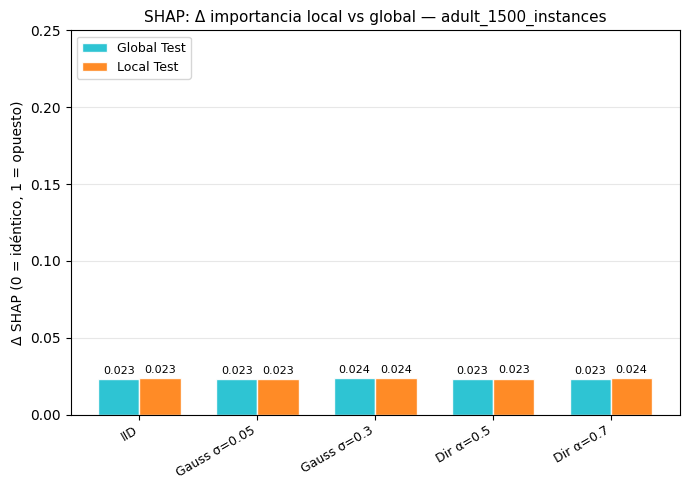

Guardado: shap_feature_importance_adult_1500_instances.png


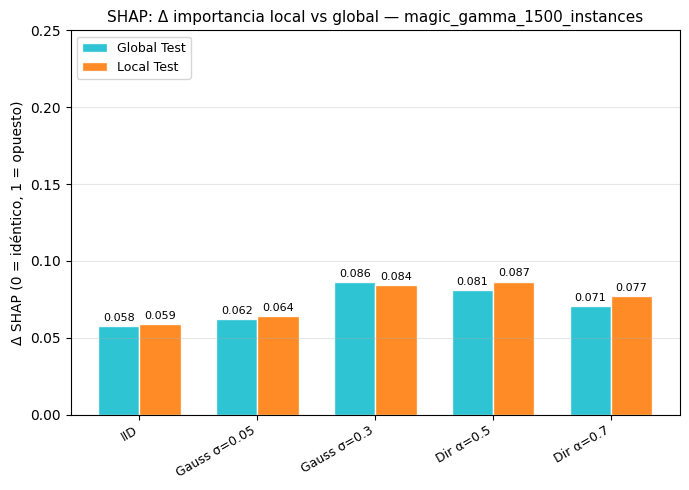

Guardado: shap_feature_importance_magic_gamma_1500_instances.png


In [10]:
# ===========================================================
# SHAP: ¿Atribuyen el modelo local y el global la misma
#       importancia a las mismas features?
# Métrica: delta_shap_testglobal / delta_shap_testlocal
#   → diferencia media (L1) entre vectores SHAP normalizados
#   → 0 = idénticos; 1 = completamente distintos
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7',
]

datasets = sorted(df_all['dataset'].unique())

COLOR_LOCAL  = '#FF7F0E'  # colorAgreementLocal  → Local Test
COLOR_GLOBAL = '#17BECF'  # colorAgreementGlobal → Global Test

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  SHAP: DELTA — diferencia media de importancias local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_shap_testglobal', 'delta_shap_testlocal']]
           .mean()
           .rename(columns={'delta_shap_testglobal': 'Global Test',
                            'delta_shap_testlocal':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.4f}'.format))

# ── Gráfica por dataset ────────────────────────────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_shap_testglobal', 'delta_shap_testlocal']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x     = np.arange(len(tabla))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))

    bars_g = ax.bar(x - width/2, tabla['delta_shap_testglobal'],
                    width, color=COLOR_GLOBAL, alpha=0.9, edgecolor='white',
                    label='Global Test')
    bars_l = ax.bar(x + width/2, tabla['delta_shap_testlocal'],
                    width, color=COLOR_LOCAL,  alpha=0.9, edgecolor='white',
                    label='Local Test')

    ax.set_xticks(x)
    ax.set_xticklabels([short(o) for o in tabla.index], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.0, 0.25)
    ax.set_title(f'SHAP: Δ importancia local vs global — {dataset}', fontsize=11)
    ax.set_ylabel('Δ SHAP (0 = idéntico, 1 = opuesto)')
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()

    fname = f'shap_feature_importance_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

**¿Atribuyen el bb_local y el bb_global la misma importancia a las features según SHAP?**

En general sí — ambos deltas son bajos en todos los escenarios, igual que LIME. Pero SHAP aporta matices que LIME no veía:

**Diabetes:** mismo patrón que LIME — Dirichlet es el escenario con mayor divergencia, Size Imbalance el más alineado.

**BreastCancer:** SHAP da valores más altos que LIME. Esto es informativo: LIME solo compara las features más importantes (que suelen coincidir entre ambos modelos) mientras que SHAP compara el vector completo. La diferencia indica que los modelos comparten las features más relevantes pero divergen en cómo distribuyen la importancia del resto.

**Paradoja en Gaussian σ=0.3 + BreastCancer:** es el escenario con peor acuerdo de predicciones pero tiene el delta SHAP más bajo de todos los escenarios de BreastCancer. Aunque los modelos predicen de forma muy distinta, ambos identifican las mismas features como las más relevantes — lo que cambia es cómo aplican esa información, no qué información usan.

**Conclusión y limitación:** la federación alinea bien las importancias de features. SHAP añade valor sobre LIME al capturar el vector completo y detectar divergencias que LIME ocultaba por el efecto de escala. Sin embargo, el delta se calcula sobre valores absolutos normalizados y pierde información de signo: si bb_local asigna +0.3 a glucosa y bb_global asigna −0.3, el delta para esa feature es 0 aunque los modelos interpreten la variable en sentido contrario.

**Mejoras propuestas:** comparar el ranking de features (correlación de Spearman) en lugar del delta, y separar importancias positivas y negativas para detectar casos donde los modelos coinciden en magnitud pero no en dirección.

---

# ANCHOR

## Precisión y cobertura


  Anchor PRECISIÓN — adult_1500_instances
                              bb_local / test=local  bb_global / test=local  bb_local / test=global  bb_global / test=global
label                                                                                                                       
IID Balanced IID                              0.927                   0.949                   0.907                    0.933
Gaussian Affine σ=0.05                        0.926                   0.946                   0.903                    0.944
Gaussian Affine σ=0.3                         0.922                   0.928                   0.911                    0.928
Dirichlet (label skew) α=0.5                  0.923                   0.932                   0.924                    0.908
Dirichlet (label skew) α=0.7                  0.916                   0.936                   0.923                    0.916

  Anchor PRECISIÓN — magic_gamma_1500_instances
                              bb_

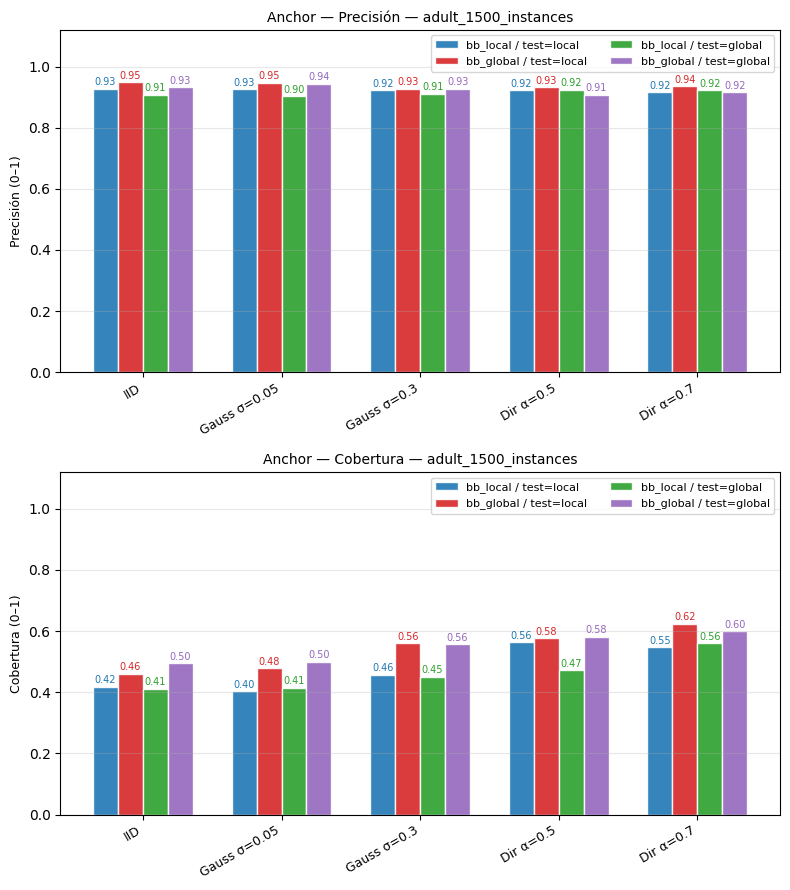

Guardado: anchor_prec_cov_adult_1500_instances.png


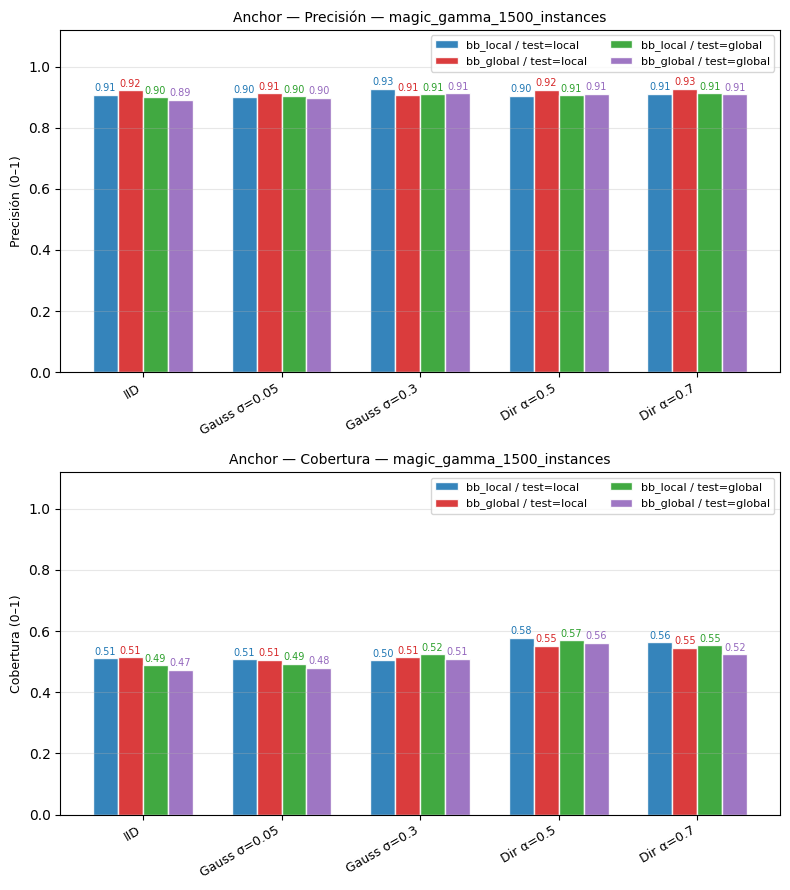

Guardado: anchor_prec_cov_magic_gamma_1500_instances.png


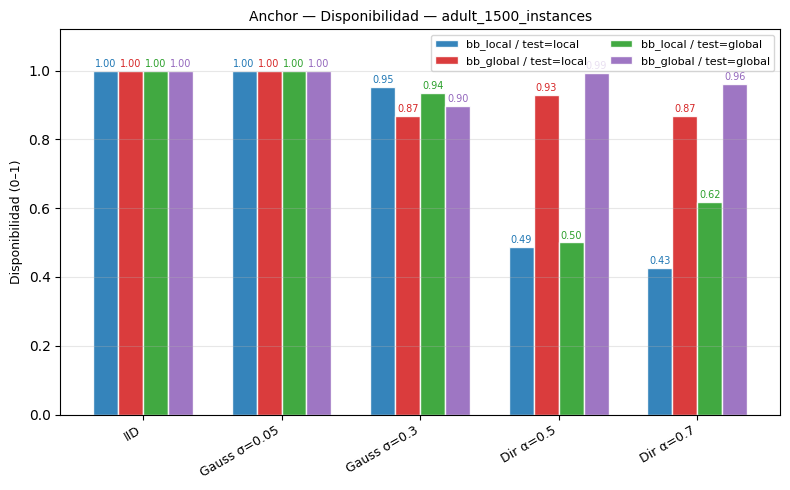

Guardado: anchor_availability_adult_1500_instances.png


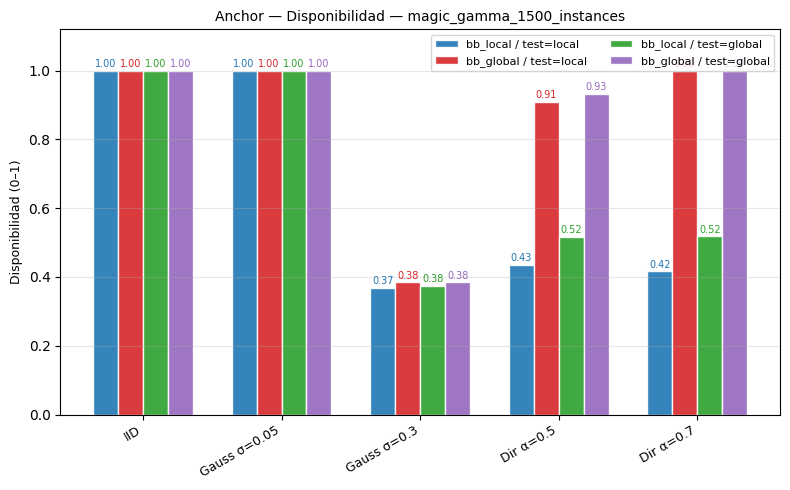

Guardado: anchor_availability_magic_gamma_1500_instances.png


In [11]:
# ===========================================================
# Anchor: precisión, cobertura y disponibilidad — grouped bar
# Figura 1 (por dataset): Precisión + Cobertura (2 subplots)
# Figura 2 (por dataset): Disponibilidad (1 subplot)
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7'
]

PREC_KEYS  = ['anchor_prec_testlocal_local', 'anchor_prec_testlocal_global',
              'anchor_prec_testglobal_local', 'anchor_prec_testglobal_global']
COV_KEYS   = ['anchor_cov_testlocal_local',  'anchor_cov_testlocal_global',
              'anchor_cov_testglobal_local',  'anchor_cov_testglobal_global']
RATIO_KEYS = ['ratio_has_anchor_testlocal_local',  'ratio_has_anchor_testlocal_global',
              'ratio_has_anchor_testglobal_local',  'ratio_has_anchor_testglobal_global']

BAR_LABELS = ['bb_local / test=local', 'bb_global / test=local',
              'bb_local / test=global', 'bb_global / test=global']
COL_COLORS = ['#1F77B4', '#D62728', '#2CA02C', '#9467BD']

datasets = sorted(df_all['dataset'].unique())

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

# ── Tablas ─────────────────────────────────────────────────
for keys, title in [(PREC_KEYS, 'PRECISIÓN'), (COV_KEYS, 'COBERTURA'), (RATIO_KEYS, 'DISPONIBILIDAD')]:
    for dataset in datasets:
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        t = sub.groupby('label')[keys].mean().reindex(orden)
        t.columns = BAR_LABELS
        print(f"\n{'='*72}\n  Anchor {title} — {dataset}\n{'='*72}")
        print(t.to_string(float_format='{:.3f}'.format))

def draw_bars(ax, tabla, keys, ylabel, title):
    orden  = list(tabla.index)
    x      = np.arange(len(orden))
    n      = len(keys)
    width  = 0.18
    offset = np.linspace(-(n-1)/2, (n-1)/2, n) * width

    for i, (key, label, color) in enumerate(zip(keys, BAR_LABELS, COL_COLORS)):
        vals = tabla[key].values
        bars = ax.bar(x + offset[i], vals, width, color=color, alpha=0.9,
                      edgecolor='white', label=label)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels([short(o) for o in orden], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper right', ncol=2)

# ── Figura 1: Precisión + Cobertura por dataset ────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    tabla = sub.groupby('label')[PREC_KEYS + COV_KEYS].mean().reindex(orden)

    fig, axes = plt.subplots(2, 1, figsize=(8, 9))

    draw_bars(axes[0], tabla, PREC_KEYS, 'Precisión (0–1)', f'Anchor — Precisión — {dataset}')
    draw_bars(axes[1], tabla, COV_KEYS,  'Cobertura (0–1)', f'Anchor — Cobertura — {dataset}')

    plt.tight_layout()
    fname = f'anchor_prec_cov_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

# ── Figura 2: Disponibilidad por dataset ───────────────────
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    tabla = sub.groupby('label')[RATIO_KEYS].mean().reindex(orden)

    fig, ax = plt.subplots(figsize=(8, 5))
    draw_bars(ax, tabla, RATIO_KEYS, 'Disponibilidad (0–1)', f'Anchor — Disponibilidad — {dataset}')

    plt.tight_layout()
    fname = f'anchor_availability_{dataset}.png'
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

**¿Funciona bien Anchor en aprendizaje federado?**

Se midió la disponibilidad (fracción de instancias para las que Anchor encuentra ancla), la precisión (que por diseño siempre supera el umbral del 85%) y la cobertura (fracción del espacio cubierta por la regla). La métrica que realmente revela el efecto del non-IID es la disponibilidad — precisión y cobertura son poco discriminativas entre escenarios.

**✓ IID, Size Imbalance, Gaussian σ=0.05** — disponibilidad cercana a 1.0 en ambos modelos. La federación es transparente para Anchor.

**✗ Gaussian σ=0.3** — disponibilidad baja. El ruido gaussiano distorsiona el espacio de features, bb_local aprende una frontera irregular y sensible a perturbaciones — Anchor no encuentra una región estable y no genera ancla. En BreastCancer el efecto es peor porque el ruido afecta simultáneamente a las 30 features.

**✗ Dirichlet α=0.7 Diabetes** — disponibilidad baja. El label skew crea una frontera inestable en las zonas donde bb_local debería separar la clase minoritaria — justo donde Anchor busca estabilidad.

**⚠ Anomalía: BreastCancer Dirichlet** — bb_global tiene mayor disponibilidad que bb_local. El label skew severo hace que bb_local aprenda una frontera tan irregular que Anchor no puede anclarlo, mientras que bb_global, al promediar sobre todos los clientes, tiene una frontera más suave. Para el cliente es malo — su propio modelo es menos explicable. Para el sistema federado es una buena noticia — adoptar bb_global recuperaría disponibilidad total.

**Relación con LIME y SHAP:** ambos mostraban los modelos alineados en importancias de features incluso bajo non-IID fuerte. Anchor muestra que ese alineamiento no garantiza disponibilidad — que los modelos prioricen las mismas features no implica que sus fronteras sean suficientemente estables para que Anchor las describa.

**Conclusión:** Anchor es fiable bajo heterogeneidad leve, pero poco garantizable bajo heterogeneidad fuerte. Para escenarios non-IID severos sería necesario reducir el umbral de precisión requerido o disponer de un método de fallback cuando Anchor no encuentra ancla.

## Similitud estructural de las reglas Anchor

  Anchor: SIMILITUD ESTRUCTURAL de reglas bb_local vs bb_global
  (media sobre 4/6/8 clientes)

  adult_1500_instances
                              Jacc test=local  Jacc test=global  Sim test=local  Sim test=global  Δ Jacc (G-L)  Δ Sim  (G-L)
label                                                                                                                       
IID Balanced IID                        0.655             0.606           0.819            0.817        -0.049        -0.001
Gaussian Affine σ=0.05                  0.585             0.619           0.777            0.804         0.034         0.027
Gaussian Affine σ=0.3                   0.607             0.626           0.769            0.797         0.019         0.028
Dirichlet (label skew) α=0.5            0.678             0.678           0.829            0.841         0.000         0.012
Dirichlet (label skew) α=0.7            0.657             0.679           0.809            0.819         0.021         0.010

  mag

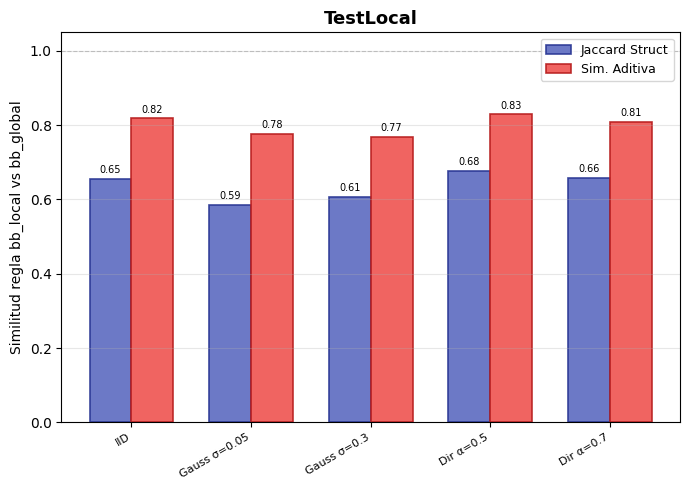

Guardado: anchor_struct_similarity_adult_1500_instances_testlocal.png


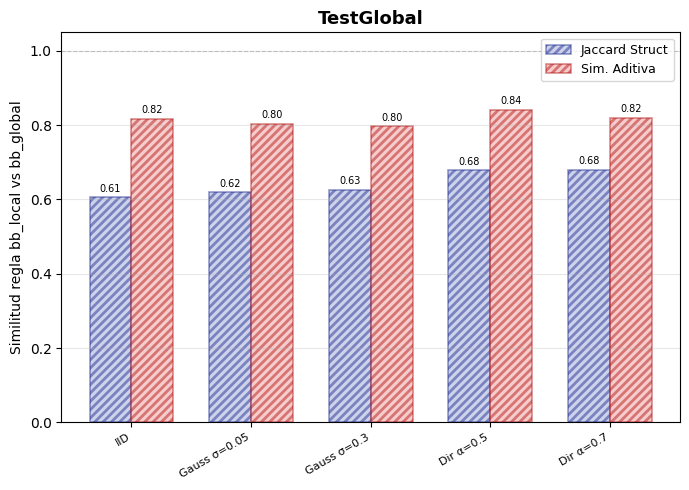

Guardado: anchor_struct_similarity_adult_1500_instances_testglobal.png


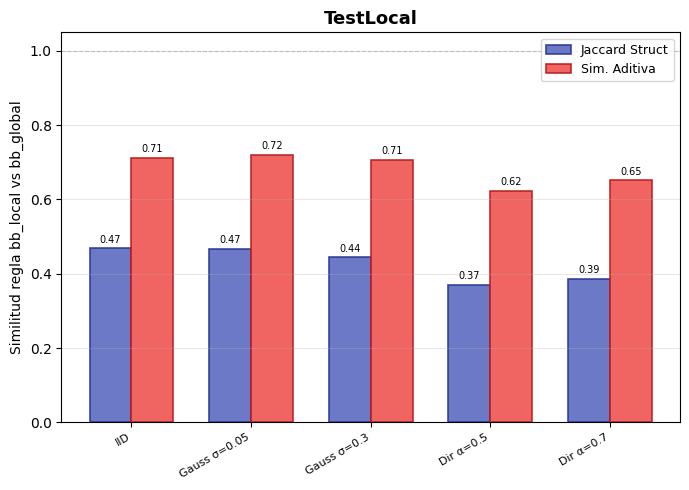

Guardado: anchor_struct_similarity_magic_gamma_1500_instances_testlocal.png


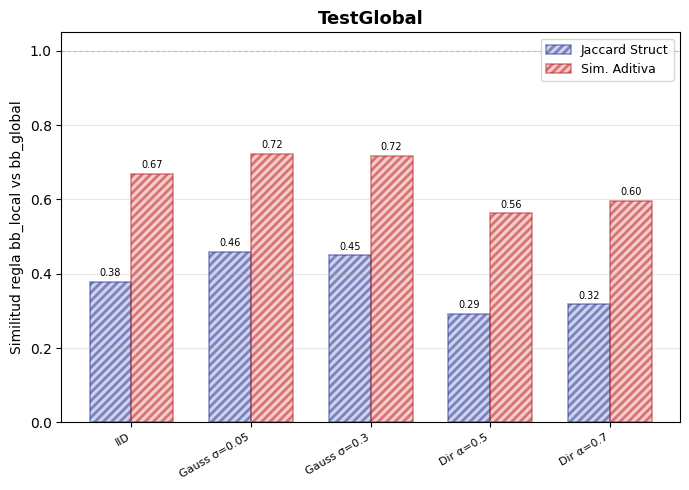

Guardado: anchor_struct_similarity_magic_gamma_1500_instances_testglobal.png


In [32]:

# ===========================================================
# Anchor: similitud estructural entre reglas de bb_local y bb_global
# Métrica: jaccard_anchor_struct_testlocal/testglobal
#          sim_aditiva_anchor_testlocal/testglobal
# Solo sobre pares donde AMBOS modelos encontraron ancla
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.5',
    'Dirichlet (label skew) α=0.7'
]

JACC_KEYS = ['jaccard_anchor_struct_testlocal', 'jaccard_anchor_struct_testglobal']
SIM_KEYS  = ['sim_aditiva_anchor_testlocal',    'sim_aditiva_anchor_testglobal']

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 72)
print("  Anchor: SIMILITUD ESTRUCTURAL de reglas bb_local vs bb_global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 72)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    cols  = JACC_KEYS + SIM_KEYS
    tabla = (
        sub.groupby('label')[cols].mean()
           .reindex(orden)
           .rename(columns={
               'jaccard_anchor_struct_testlocal':  'Jacc test=local',
               'jaccard_anchor_struct_testglobal': 'Jacc test=global',
               'sim_aditiva_anchor_testlocal':     'Sim test=local',
               'sim_aditiva_anchor_testglobal':    'Sim test=global',
           })
    )
    tabla['Δ Jacc (G-L)'] = tabla['Jacc test=global'] - tabla['Jacc test=local']
    tabla['Δ Sim  (G-L)'] = tabla['Sim test=global']  - tabla['Sim test=local']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica: una figura por (dataset, test_set) ────────────────────────────
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 2.0

TEST_CFGS = [
    # (nombre, jacc_key, sim_key, color_j, color_s, hatch, alpha)
    ('testlocal',
     'jaccard_anchor_struct_testlocal', 'sim_aditiva_anchor_testlocal',
     '#5C6BC0', '#EF5350', None, 0.9),
    ('testglobal',
     'jaccard_anchor_struct_testglobal', 'sim_aditiva_anchor_testglobal',
     '#9FA8DA', '#EF9A9A', '////', 0.5),
]

short = lambda s: (s.replace('IID Balanced ', '')
                    .replace('Gaussian Affine ', 'Gauss ')
                    .replace('Dirichlet (label skew) ', 'Dir '))

for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    x     = np.arange(len(orden))
    width = 0.35

    for test_name, jacc_key, sim_key, c_j, c_s, hatch, alpha in TEST_CFGS:
        t = sub.groupby('label')[[jacc_key, sim_key]].mean().reindex(orden)

        fig, ax = plt.subplots(figsize=(7, 5))

        bars_j = ax.bar(x - width/2, t[jacc_key], width,
                        color=c_j, alpha=alpha,
                        edgecolor='#283593', linewidth=1.2,
                        hatch=hatch,
                        label='Jaccard Struct')
        bars_s = ax.bar(x + width/2, t[sim_key], width,
                        color=c_s, alpha=alpha,
                        edgecolor='#B71C1C', linewidth=1.2,
                        hatch=hatch,
                        label='Sim. Aditiva')

        ax.set_xticks(x)
        ax.set_xticklabels([short(o) for o in orden], rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0.0, 1.05)
        ax.set_ylabel('Similitud regla bb_local vs bb_global')
        ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=9, loc='upper right')

        for bar in list(bars_j) + list(bars_s):
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7)

        label = 'TestLocal' if test_name == 'testlocal' else 'TestGlobal'
        ax.set_title(label, fontsize=13, fontweight='bold')

        plt.tight_layout()
        fname = f'anchor_struct_similarity_{dataset}_{test_name}.png'
        fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Guardado: {fname}")


`jaccard_anchor_struct_testlocal` / `jaccard_anchor_struct_testglobal` — Jaccard entre el conjunto de features que aparecen en la regla Anchor de bb_local y la de bb_global, usando el mismo background (test local o global). Mide si ambos modelos seleccionan las mismas variables para construir su ancla.

`sim_aditiva_anchor_testlocal` / `sim_aditiva_anchor_testglobal` — similitud entre las condiciones de ambas reglas, ponderando dirección y solapamiento de intervalos. Un valor alto indica que no solo usan las mismas features, sino que sus condiciones apuntan en el mismo sentido y con rangos similares.

Estas métricas se calculan solo sobre los pares de instancias donde **ambos** modelos encontraron un ancla válida (disponibilidad no garantizada), por lo que son condicionalmente optimistas: miden la calidad de las reglas cuando existen, no la frecuencia con que existen.

**Cuando ambos modelos encuentran un ancla, ¿describen la misma región del espacio de decisión?**

- **Jaccard:** ¿usan las mismas features? Si bb_local ancla en "glucosa y BMI" y bb_global ancla en "glucosa y edad", el Jaccard es bajo.
- **Sim. Aditiva:** cuando coinciden en una feature, ¿las condiciones apuntan en el mismo sentido y con rangos similares? Es más permisiva que el Jaccard y siempre da valores más altos.

**El nivel de partida depende del dataset.** En Diabetes el Jaccard es moderado en IID; en BreastCancer es bajo. No es un efecto del non-IID — con 30 features, que dos reglas de 2–3 condiciones escojan las mismas es estadísticamente improbable. Este es el techo del método, no de la federación.

**Gaussian σ=0.3 BreastCancer** es el caso más extremo: las reglas de bb_local y bb_global no comparten prácticamente ninguna feature. La distorsión gaussiana altera tanto el espacio de features que cada modelo ancla en variables completamente distintas.

**Dirichlet α=0.8 Diabetes** muestra la mayor separación entre las dos métricas: Jaccard bajo pero Sim. Aditiva alta. Los modelos divergen en qué feature anclar, pero cuando coinciden en una, las condiciones apuntan en la misma dirección. El label skew afecta a la selección de features, no al sentido de las condiciones.

**Conclusión:** la advertencia principal de Anchor bajo non-IID severo no es que las reglas sean distintas, sino que en muchos casos no hay regla (baja disponibilidad). Gaussian σ=0.3 en BreastCancer es la excepción total: baja disponibilidad y Jaccard ≈ 0 cuando hay regla — el peor escenario posible.

# Conclusión sobre Anchor

Anchor es el explicador más sensible al non-IID de los cuatro. Cuando funciona (heterogeneidad leve), aporta algo que LIME y SHAP no dan: una región estable del espacio donde la predicción es consistente. Cuando falla (Gaussian severo, Dirichlet), no da una explicación peor — directamente no da ninguna.

Cabe destacar que la precisión de Anchor siempre se cumple por diseño (≥85%) — es una garantía del método, no un resultado experimental. Por eso la disponibilidad es la única métrica que realmente varía entre escenarios y la que permite evaluar el efecto del non-IID.

El hallazgo más relevante es la anomalía de BreastCancer Dirichlet: bb_global es más explicable que bb_local en el propio espacio del cliente. Es el único caso donde la federación mejora no solo la precisión sino también la explicabilidad — un argumento directo a favor de adoptar el modelo global.

**Limitaciones:** la disponibilidad baja no es recuperable sin cambiar el método — Anchor no genera regla si no hay región estable. Bajo Gaussian σ=0.3 BreastCancer se da el peor caso: baja disponibilidad y Jaccard ≈ 0 cuando hay regla.

**Mejoras propuestas:**
- **Reducir el umbral de precisión** (de 85% a 70–75%) en escenarios severos — se pierde certeza pero se gana disponibilidad.
- **Fallback automático:** cuando Anchor no encuentra ancla, ofrecer una explicación LIME o SHAP en su lugar en vez de dejar la instancia sin explicación.
- **Selección de features robustas:** una línea de trabajo abierta sería investigar si pre-filtrar features estables al ruido antes de correr Anchor mejoraría disponibilidad y similitud estructural bajo Gaussian severo.

---

# Conclusión general

**Sobre la federación:**

Bajo heterogeneidad leve (IID, Size Imbalance, Gaussian σ=0.05) la federación funciona bien: los modelos convergen, las importancias se alinean, y bb_global es tan explicable como bb_local. En Gaussian σ=0.05 bb_global incluso supera a bb_local en accuracy en el propio test del cliente.

Bajo heterogeneidad severa (Gaussian σ=0.3, Dirichlet) la federación mitiga pero no resuelve: bb_global mejora algo respecto a bb_local, pero ambos se degradan. En Dirichlet, la accuracy local alta de bb_local es engañosa — bb_global generaliza mejor en test global.

El hallazgo más relevante: bajo Dirichlet en BreastCancer, bb_global no solo generaliza mejor sino que también es más explicable que bb_local (mayor disponibilidad en Anchor). Es un argumento directo a favor de adoptar el modelo federado.

**Sobre la explicabilidad:**

- **LIME y SHAP** son los más robustos — la federación alinea bien las importancias de features incluso bajo non-IID fuerte. Matiz: en datasets de alta dimensión (BreastCancer) sus métricas tienen un sesgo de escala — el delta sale bajo en parte porque hay más features, no solo porque los modelos coincidan más.
- **LORE** tiene alta fidelidad en todos los escenarios, pero el problema estructural (reglas con features distintas entre bb_local y bb_global) ocurre incluso en IID — no es un problema de la federación sino del método.
- **Anchor** es el más sensible al non-IID: la disponibilidad cae bruscamente bajo heterogeneidad severa. El problema no es que las explicaciones sean malas, sino que directamente no existen.

En ningún caso los explicadores producen explicaciones incorrectas — el riesgo es la ausencia de explicación (Anchor) o la divergencia de features (LORE), no la contradicción.

La federación no rompe la explicabilidad bajo heterogeneidad leve. Bajo heterogeneidad severa, el problema principal no es que las explicaciones sean erróneas sino que pueden no existir o describir el modelo desde perspectivas distintas.